## 1. 数据生成与导出（7天需求 + 可扩展实例）

In [2]:
import os
import numpy as np
import pandas as pd

# 设置随机种子
np.random.seed(42)

# 统一输出目录
data_dir = "datas"
os.makedirs(data_dir, exist_ok=True)

# 场景 1：生成 Advanced Model 的 7 天动态需求
def generate_7day_demand(base_demands, variance=0.2, days=7):
    """
    基于基础需求，生成带有均匀分布随机扰动的 7 天需求矩阵。
    数学公式：d_{it} = max(0, round(d_i * (1 + epsilon)))，其中 epsilon ~ U(-variance, variance)
    """
    num_customers = len(base_demands)

    perturbations = np.random.uniform(-variance, variance, size=(num_customers, days))
    base_matrix = np.tile(base_demands, (days, 1)).T
    daily_demands = base_matrix * (1 + perturbations)
    daily_demands = np.round(daily_demands).astype(int)
    daily_demands = np.maximum(daily_demands, 0)

    df_demands = pd.DataFrame(
        daily_demands,
        columns=[f"Day_{t}" for t in range(1, days + 1)],
        index=[f"C{i}" for i in range(1, num_customers + 1)],
    )
    return df_demands


# 场景 2：生成新的 scalability instance
def generate_scalability_instance(num_customers, num_locations, max_distance=220, space_size=500):
    """
    在二维网格中生成包含坐标、距离、基础需求和偏好矩阵的完整实例。
    距离采用曼哈顿距离（L1）：|x1-x2| + |y1-y2|
    """
    cust_coords = np.random.uniform(0, space_size, size=(num_customers, 2))
    loc_coords = np.random.uniform(0, space_size, size=(num_locations, 2))

    demands = np.random.randint(20, 81, size=num_customers)

    diff = cust_coords[:, np.newaxis, :] - loc_coords[np.newaxis, :, :]
    distances = np.abs(diff).sum(axis=-1)

    alphas = 1 - (distances / max_distance)
    alphas = np.maximum(alphas, 0)
    alphas = np.round(alphas, 2)

    return {
        "demands": demands,
        "distances": distances,
        "alphas": alphas,
        "cust_coords": cust_coords,
        "loc_coords": loc_coords,
    }


# 执行与导出 CSV
base_d = np.array([65, 40, 55, 30, 75, 50, 60, 35, 45, 70])
df_7day = generate_7day_demand(base_d)
df_7day.to_csv(os.path.join(data_dir, "advanced_model_7day_demand.csv"))
print("成功导出: datas/advanced_model_7day_demand.csv")

test_cust_num = 10
test_loc_num = 8
instance = generate_scalability_instance(
    num_customers=test_cust_num,
    num_locations=test_loc_num,
    max_distance=220,
)

# 1) 偏好矩阵 alpha_ij
df_alphas = pd.DataFrame(
    instance["alphas"],
    columns=[f"T{j + 1}" for j in range(test_loc_num)],
    index=[f"C{i + 1}" for i in range(test_cust_num)],
)
df_alphas.to_csv(os.path.join(data_dir, "scalability_alpha_matrix.csv"))
print("成功导出: datas/scalability_alpha_matrix.csv")

# 2) 顾客信息（基础需求 + 坐标）
df_cust = pd.DataFrame(
    {
        "Base_Demand": instance["demands"],
        "X_Coord": np.round(instance["cust_coords"][:, 0], 2),
        "Y_Coord": np.round(instance["cust_coords"][:, 1], 2),
    },
    index=[f"C{i + 1}" for i in range(test_cust_num)],
)
df_cust.to_csv(os.path.join(data_dir, "scalability_customer_data.csv"))
print("成功导出: datas/scalability_customer_data.csv")

# 3) 餐车候选位置坐标
df_loc = pd.DataFrame(
    {
        "X_Coord": np.round(instance["loc_coords"][:, 0], 2),
        "Y_Coord": np.round(instance["loc_coords"][:, 1], 2),
    },
    index=[f"T{j + 1}" for j in range(test_loc_num)],
)
df_loc.to_csv(os.path.join(data_dir, "scalability_location_coords.csv"))
print("成功导出: datas/scalability_location_coords.csv")

print("finished!")

成功导出: datas/advanced_model_7day_demand.csv
成功导出: datas/scalability_alpha_matrix.csv
成功导出: datas/scalability_customer_data.csv
成功导出: datas/scalability_location_coords.csv
finished!


## 2. Basic Model：单日选址分配（PuLP）与可视化

In [3]:
import os
import numpy as np
import pulp
import pandas as pd
import matplotlib.pyplot as plt

# 1. 初始化数据
customers = [f"C{i+1}" for i in range(10)]
locations = [f"T{j+1}" for j in range(8)]

r, k, f = 10.0, 5.0, 250.0

demands = {
    "C1": 65, "C2": 40, "C3": 55, "C4": 30, "C5": 75,
    "C6": 50, "C7": 60, "C8": 35, "C9": 45, "C10": 70,
}

alpha = {
    "C1":  {"T1": 0.9, "T2": 0.7, "T3": 0.2, "T4": 0.1, "T5": 0.0, "T6": 0.3, "T7": 0.6, "T8": 0.4},
    "C2":  {"T1": 0.4, "T2": 0.8, "T3": 0.1, "T4": 0.0, "T5": 0.6, "T6": 0.2, "T7": 0.3, "T8": 0.7},
    "C3":  {"T1": 0.2, "T2": 0.3, "T3": 0.9, "T4": 0.5, "T5": 0.1, "T6": 0.0, "T7": 0.6, "T8": 0.4},
    "C4":  {"T1": 0.1, "T2": 0.0, "T3": 0.4, "T4": 0.8, "T5": 0.9, "T6": 0.3, "T7": 0.5, "T8": 0.2},
    "C5":  {"T1": 0.7, "T2": 0.6, "T3": 0.3, "T4": 0.0, "T5": 0.4, "T6": 0.9, "T7": 0.1, "T8": 0.5},
    "C6":  {"T1": 0.5, "T2": 0.2, "T3": 0.1, "T4": 0.3, "T5": 0.6, "T6": 0.4, "T7": 0.8, "T8": 0.7},
    "C7":  {"T1": 0.3, "T2": 0.4, "T3": 0.0, "T4": 0.6, "T5": 0.2, "T6": 0.1, "T7": 0.9, "T8": 0.8},
    "C8":  {"T1": 0.6, "T2": 0.5, "T3": 0.7, "T4": 0.1, "T5": 0.3, "T6": 0.0, "T7": 0.2, "T8": 0.9},
    "C9":  {"T1": 0.2, "T2": 0.1, "T3": 0.6, "T4": 0.9, "T5": 0.4, "T6": 0.8, "T7": 0.0, "T8": 0.3},
    "C10": {"T1": 0.8, "T2": 0.3, "T3": 0.5, "T4": 0.2, "T5": 0.7, "T6": 0.1, "T7": 0.4, "T8": 0.6},
}

# 2. 构建模型
prob = pulp.LpProblem("Dumplings_Basic_Model", pulp.LpMaximize)

x = pulp.LpVariable.dicts("x", locations, cat=pulp.LpBinary)
y = pulp.LpVariable.dicts("y", (customers, locations), cat=pulp.LpBinary)

profit = pulp.lpSum((r - k) * alpha[i][j] * demands[i] * y[i][j] for i in customers for j in locations) \
         - pulp.lpSum(f * x[j] for j in locations)
prob += profit

for i in customers:
    prob += pulp.lpSum(y[i][j] for j in locations) <= 1, f"C1_MaxOneTruck_{i}"

for i in customers:
    for j in locations:
        prob += y[i][j] <= x[j], f"C2_OnlyOpenTruck_{i}_{j}"

# 3. 求解
prob.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"求解状态: {pulp.LpStatus[prob.status]}")
print(f"最优总利润: CNY {pulp.value(prob.objective):.2f}\n")

print("【决策变量 x_j】")
x_results = []
for j in locations:
    val = pulp.value(x[j])
    status = "部署" if val == 1 else "不部署"
    x_results.append({"位置": j, "变量取值": int(val), "状态": status})
print(pd.DataFrame(x_results).to_string(index=False))

print("\n【决策变量 y_ij】")
y_active = []
for i in customers:
    assigned = False
    for j in locations:
        if pulp.value(y[i][j]) == 1:
            y_active.append(
                {
                    "顾客": i,
                    "分配位置": j,
                    "偏好得分(alpha)": alpha[i][j],
                    "贡献利润": (r - k) * alpha[i][j] * demands[i],
                }
            )
            assigned = True
    if not assigned:
        y_active.append({"顾客": i, "分配位置": "未分配", "偏好得分(alpha)": 0, "贡献利润": 0})

print(pd.DataFrame(y_active).to_string(index=False))
print("\n提示：Basic 可视化已移动到第 9 个单元（反解坐标之后）。")

求解状态: Optimal
最优总利润: CNY 1285.00

【决策变量 x_j】
位置  变量取值  状态
T1     1  部署
T2     0 不部署
T3     0 不部署
T4     1  部署
T5     0 不部署
T6     0 不部署
T7     0 不部署
T8     0 不部署

【决策变量 y_ij】
 顾客 分配位置  偏好得分(alpha)  贡献利润
 C1   T1          0.9 292.5
 C2   T1          0.4  80.0
 C3   T4          0.5 137.5
 C4   T4          0.8 120.0
 C5   T1          0.7 262.5
 C6   T1          0.5 125.0
 C7   T4          0.6 180.0
 C8   T1          0.6 105.0
 C9   T4          0.9 202.5
C10   T1          0.8 280.0

提示：Basic 可视化已移动到第 9 个单元（反解坐标之后）。


## 3. 偏好矩阵反解坐标（用于更自然的图示）

Inverse coordinates solved. Alpha-fit RMSE: 0.2036
Distance metric: Manhattan (L1)
Parameters: FIT_WEIGHT=1.0, SERVICE_WEIGHT=0.18, MIN_SEP=50.0, SEP_WEIGHT=0.002, REG_WEIGHT=0.0008
Service pairs: 10, avg service distance: 88.72, max service distance: 127.10


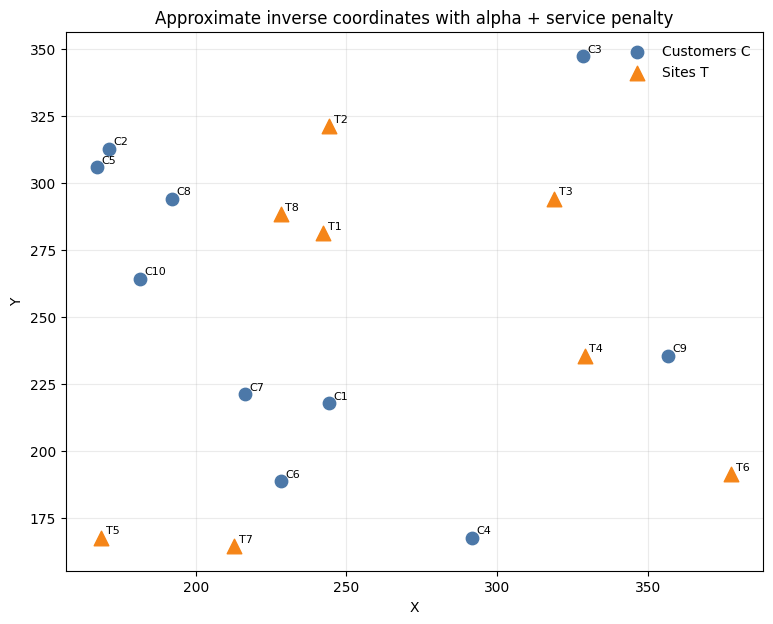

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# Approximate inverse-coordinate fitting from fixed alpha matrix (2D)
# Assumed relation (Manhattan distance): alpha_ij ≈ max(0, 1 - (|dx| + |dy|) / D)
D = 220.0

# Fit strategy: keep alpha fit while adding service-distance penalty for a more natural layout
FIT_WEIGHT = 1.0
SERVICE_WEIGHT = 0.18
MIN_SEP = 50.0
SEP_WEIGHT = 0.002
REG_WEIGHT = 8e-4

if "customers" not in globals() or "locations" not in globals() or "alpha" not in globals():
    raise ValueError("Please run the previous basic-model cell to provide customers/locations/alpha.")

n_c = len(customers)
n_l = len(locations)
A_obs = np.array([[alpha[i][j] for j in locations] for i in customers], dtype=float)

# Extract realized assignments from basic model as regularization
service_pairs = []
if "y" in globals() and all(i_name in y for i_name in customers):
    for i_idx, i_name in enumerate(customers):
        for j_idx, j_name in enumerate(locations):
            val = y[i_name][j_name].value()
            if val is not None and val > 0.5:
                service_pairs.append((i_idx, j_idx))


def unpack(theta):
    c = theta[: 2 * n_c].reshape(n_c, 2)
    l = theta[2 * n_c :].reshape(n_l, 2)
    return c, l


def pairwise_sep_penalty(points, min_sep):
    if len(points) <= 1:
        return np.array([], dtype=float)

    diff = points[:, None, :] - points[None, :, :]
    dist = np.abs(diff).sum(axis=2)

    iu = np.triu_indices(len(points), k=1)
    dist_u = dist[iu]
    penalty = np.clip(min_sep - dist_u, 0.0, None)
    return penalty


def residuals(theta):
    c, l = unpack(theta)
    diff = c[:, None, :] - l[None, :, :]
    dist = np.abs(diff).sum(axis=2)
    A_pred = np.clip(1.0 - dist / D, 0.0, 1.0)

    fit_res = FIT_WEIGHT * (A_pred - A_obs).ravel()

    if service_pairs:
        service_dist = np.array([dist[i_idx, j_idx] for i_idx, j_idx in service_pairs], dtype=float)
        service_res = SERVICE_WEIGHT * (service_dist / D)
    else:
        service_res = np.array([], dtype=float)

    sep_res_c = pairwise_sep_penalty(c, MIN_SEP)
    sep_res_l = pairwise_sep_penalty(l, MIN_SEP)
    sep_res = SEP_WEIGHT * np.concatenate([sep_res_c, sep_res_l])

    reg = REG_WEIGHT * theta
    return np.concatenate([fit_res, service_res, sep_res, reg])


# Multi-start initialization
best = None
best_cost = np.inf
rng = np.random.default_rng(42)

for _ in range(12):
    theta0 = rng.normal(loc=200.0, scale=120.0, size=2 * (n_c + n_l))
    result = least_squares(residuals, theta0, method="trf", max_nfev=6000)
    if result.cost < best_cost:
        best_cost = result.cost
        best = result

cust_xy, loc_xy = unpack(best.x)

# Shift to readable center area
all_xy = np.vstack([cust_xy, loc_xy])
center = all_xy.mean(axis=0)
target_center = np.array([250.0, 250.0])
shift = target_center - center
cust_xy = cust_xy + shift
loc_xy = loc_xy + shift

# Fit error
diff_best = cust_xy[:, None, :] - loc_xy[None, :, :]
dist_best = np.abs(diff_best).sum(axis=2)
A_fit = np.clip(1.0 - dist_best / D, 0.0, 1.0)
rmse = np.sqrt(np.mean((A_fit - A_obs) ** 2))

if service_pairs:
    service_dist_raw = [dist_best[i_idx, j_idx] for i_idx, j_idx in service_pairs]
    avg_service_dist = float(np.mean(service_dist_raw))
    max_service_dist = float(np.max(service_dist_raw))
else:
    avg_service_dist = float("nan")
    max_service_dist = float("nan")

print(f"Inverse coordinates solved. Alpha-fit RMSE: {rmse:.4f}")
print("Distance metric: Manhattan (L1)")
print(
    f"Parameters: FIT_WEIGHT={FIT_WEIGHT}, SERVICE_WEIGHT={SERVICE_WEIGHT}, "
    f"MIN_SEP={MIN_SEP}, SEP_WEIGHT={SEP_WEIGHT}, REG_WEIGHT={REG_WEIGHT}"
)
print(f"Service pairs: {len(service_pairs)}, avg service distance: {avg_service_dist:.2f}, max service distance: {max_service_dist:.2f}")

plt.figure(figsize=(9, 7))
plt.scatter(cust_xy[:, 0], cust_xy[:, 1], s=80, c="#4C78A8", label="Customers C")
plt.scatter(loc_xy[:, 0], loc_xy[:, 1], s=110, c="#F58518", marker="^", label="Sites T")

for idx, name in enumerate(customers):
    plt.text(cust_xy[idx, 0] + 1.5, cust_xy[idx, 1] + 1.5, name, fontsize=8)
for idx, name in enumerate(locations):
    plt.text(loc_xy[idx, 0] + 1.5, loc_xy[idx, 1] + 1.5, name, fontsize=8)

plt.title("Approximate inverse coordinates with alpha + service penalty")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(frameon=False)
plt.grid(alpha=0.25)
plt.show()

## 3.5 Basic Model 可视化（基于反解坐标）

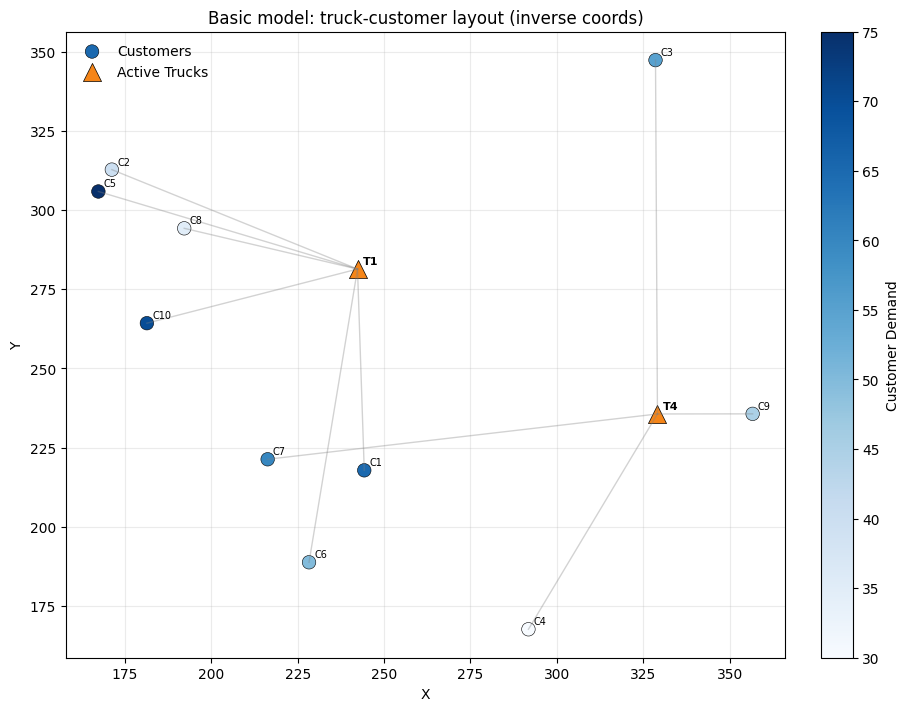

In [5]:
# Basic 可视化：放在反解坐标之后，统一使用 inverse coords
if "cust_xy" not in globals() or "loc_xy" not in globals():
    raise ValueError("请先运行上一单元完成反解坐标。")

if "customers" not in globals() or "locations" not in globals() or "demands" not in globals() or "x" not in globals() or "y" not in globals():
    raise ValueError("请先运行第6个单元完成 Basic 模型求解。")

cust_xy_map = {customers[i]: cust_xy[i] for i in range(len(customers))}
loc_xy_map = {locations[j]: loc_xy[j] for j in range(len(locations))}
coord_tag = "inverse coords"

fig, ax = plt.subplots(1, 1, figsize=(9, 7), constrained_layout=True)

demand_values = [demands[c] for c in customers]
xs = [cust_xy_map[c][0] for c in customers]
ys = [cust_xy_map[c][1] for c in customers]
sc = ax.scatter(xs, ys, c=demand_values, cmap="Blues", s=95, edgecolors="black", linewidths=0.4, label="Customers")

active_locations = [j for j in locations if pulp.value(x[j]) > 0.5]
if active_locations:
    lx = [loc_xy_map[j][0] for j in active_locations]
    ly = [loc_xy_map[j][1] for j in active_locations]
    ax.scatter(lx, ly, marker="^", s=170, c="#F58518", edgecolors="black", linewidths=0.5, label="Active Trucks")

for c in customers:
    assigned_loc = None
    for j in locations:
        if pulp.value(y[c][j]) > 0.5:
            assigned_loc = j
            break
    if assigned_loc is not None:
        x1, y1 = cust_xy_map[c]
        x2, y2 = loc_xy_map[assigned_loc]
        ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.35, linewidth=1.0)

for c in customers:
    x_c, y_c = cust_xy_map[c]
    ax.text(x_c + 1.5, y_c + 1.5, c, fontsize=7)
for j in active_locations:
    x_j, y_j = loc_xy_map[j]
    ax.text(x_j + 1.5, y_j + 1.5, j, fontsize=8, fontweight="bold")

ax.set_title(f"Basic model: truck-customer layout ({coord_tag})")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc="best")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Customer Demand")
plt.show()

## 4. Basic Model 的 LP 松弛分析

In [6]:
import os
import pandas as pd
import pulp

# 1. 复制模型并将变量类型改为连续变量 [0,1]
prob_lp = pulp.LpProblem("Dumplings_Basic_LP", pulp.LpMaximize)

x_lp = pulp.LpVariable.dicts("x_lp", locations, lowBound=0, upBound=1, cat=pulp.LpContinuous)
y_lp = pulp.LpVariable.dicts("y_lp", (customers, locations), lowBound=0, upBound=1, cat=pulp.LpContinuous)

# 2. 目标函数
prob_lp += pulp.lpSum((r - k) * alpha[i][j] * demands[i] * y_lp[i][j] for i in customers for j in locations) \
           - pulp.lpSum(f * x_lp[j] for j in locations)

# 3. 约束
for i in customers:
    prob_lp += pulp.lpSum(y_lp[i][j] for j in locations) <= 1, f"UniqueServe_{i}"
    for j in locations:
        prob_lp += y_lp[i][j] <= x_lp[j], f"LinkTruck_{i}_{j}"

# 4. 求解
prob_lp.solve(pulp.PULP_CBC_CMD(msg=0))

# 5. 指标对比
ip_obj = pulp.value(prob.objective)
lp_obj = pulp.value(prob_lp.objective)
gap = (lp_obj - ip_obj) / ip_obj * 100 if ip_obj != 0 else 0

print("--- 基础模型对照 ---")
print(f"IP 最优利润: {ip_obj:.2f}")
print(f"LP 松弛利润: {lp_obj:.2f}")
print(f"Integrality Gap: {gap:.2f}%\n")

# 6. 导出结构化洞察
fractional_data = []
for j in locations:
    val = pulp.value(x_lp[j])
    if 0 < val < 1:
        fractional_data.append({"位置": j, "LP取值": round(val, 4), "备注": "分数解(半开启)"})

binding_data = []
for name, c in prob_lp.constraints.items():
    if abs(c.slack) < 1e-7:
        binding_data.append({"约束名称": name, "松弛量(Slack)": round(c.slack, 6), "状态": "紧约束/达到边界"})

os.makedirs("datas", exist_ok=True)
df_fractional = pd.DataFrame(fractional_data)
df_binding = pd.DataFrame(binding_data)
df_summary = pd.DataFrame([
    {"IP_Profit": ip_obj, "LP_Profit": lp_obj, "Integrality_Gap_Percent": gap}
])

df_fractional.to_csv(os.path.join("datas", "basic_lp_fractional_vars.csv"), index=False, encoding="utf-8-sig")
df_binding.to_csv(os.path.join("datas", "basic_lp_binding_constraints.csv"), index=False, encoding="utf-8-sig")
df_summary.to_csv(os.path.join("datas", "basic_lp_summary_comparison.csv"), index=False, encoding="utf-8-sig")

print("【结果导出状态】")
print(f"- 分数解已导出: {len(df_fractional)} 条")
print(f"- 紧约束已导出: {len(df_binding)} 条")
print("所有 LP 分析结果已保存至 CSV 文件。")

--- 基础模型对照 ---
IP 最优利润: 1285.00
LP 松弛利润: 1293.75
Integrality Gap: 0.68%

【结果导出状态】
- 分数解已导出: 4 条
- 紧约束已导出: 70 条
所有 LP 分析结果已保存至 CSV 文件。


## 5. Advanced Model（7天）求解与可视化（Gurobi）

Restricted license - for non-production use only - expires 2027-11-29
7天总利润 (含波动与容量限制): CNY 8730.00
平均单日利润: CNY 1247.14
结果已保存至 datas/advanced_10_cust_strict_comparison.csv

--- 每日车型部署摘要 ---
Truck_Type  Large  Medium  Small
Day                             
Day_1         1.0     0.0    2.0
Day_2         0.0     1.0    3.0
Day_3         0.0     1.0    3.0
Day_4         0.0     2.0    1.0
Day_5         1.0     1.0    1.0
Day_6         0.0     1.0    3.0
Day_7         1.0     1.0    1.0


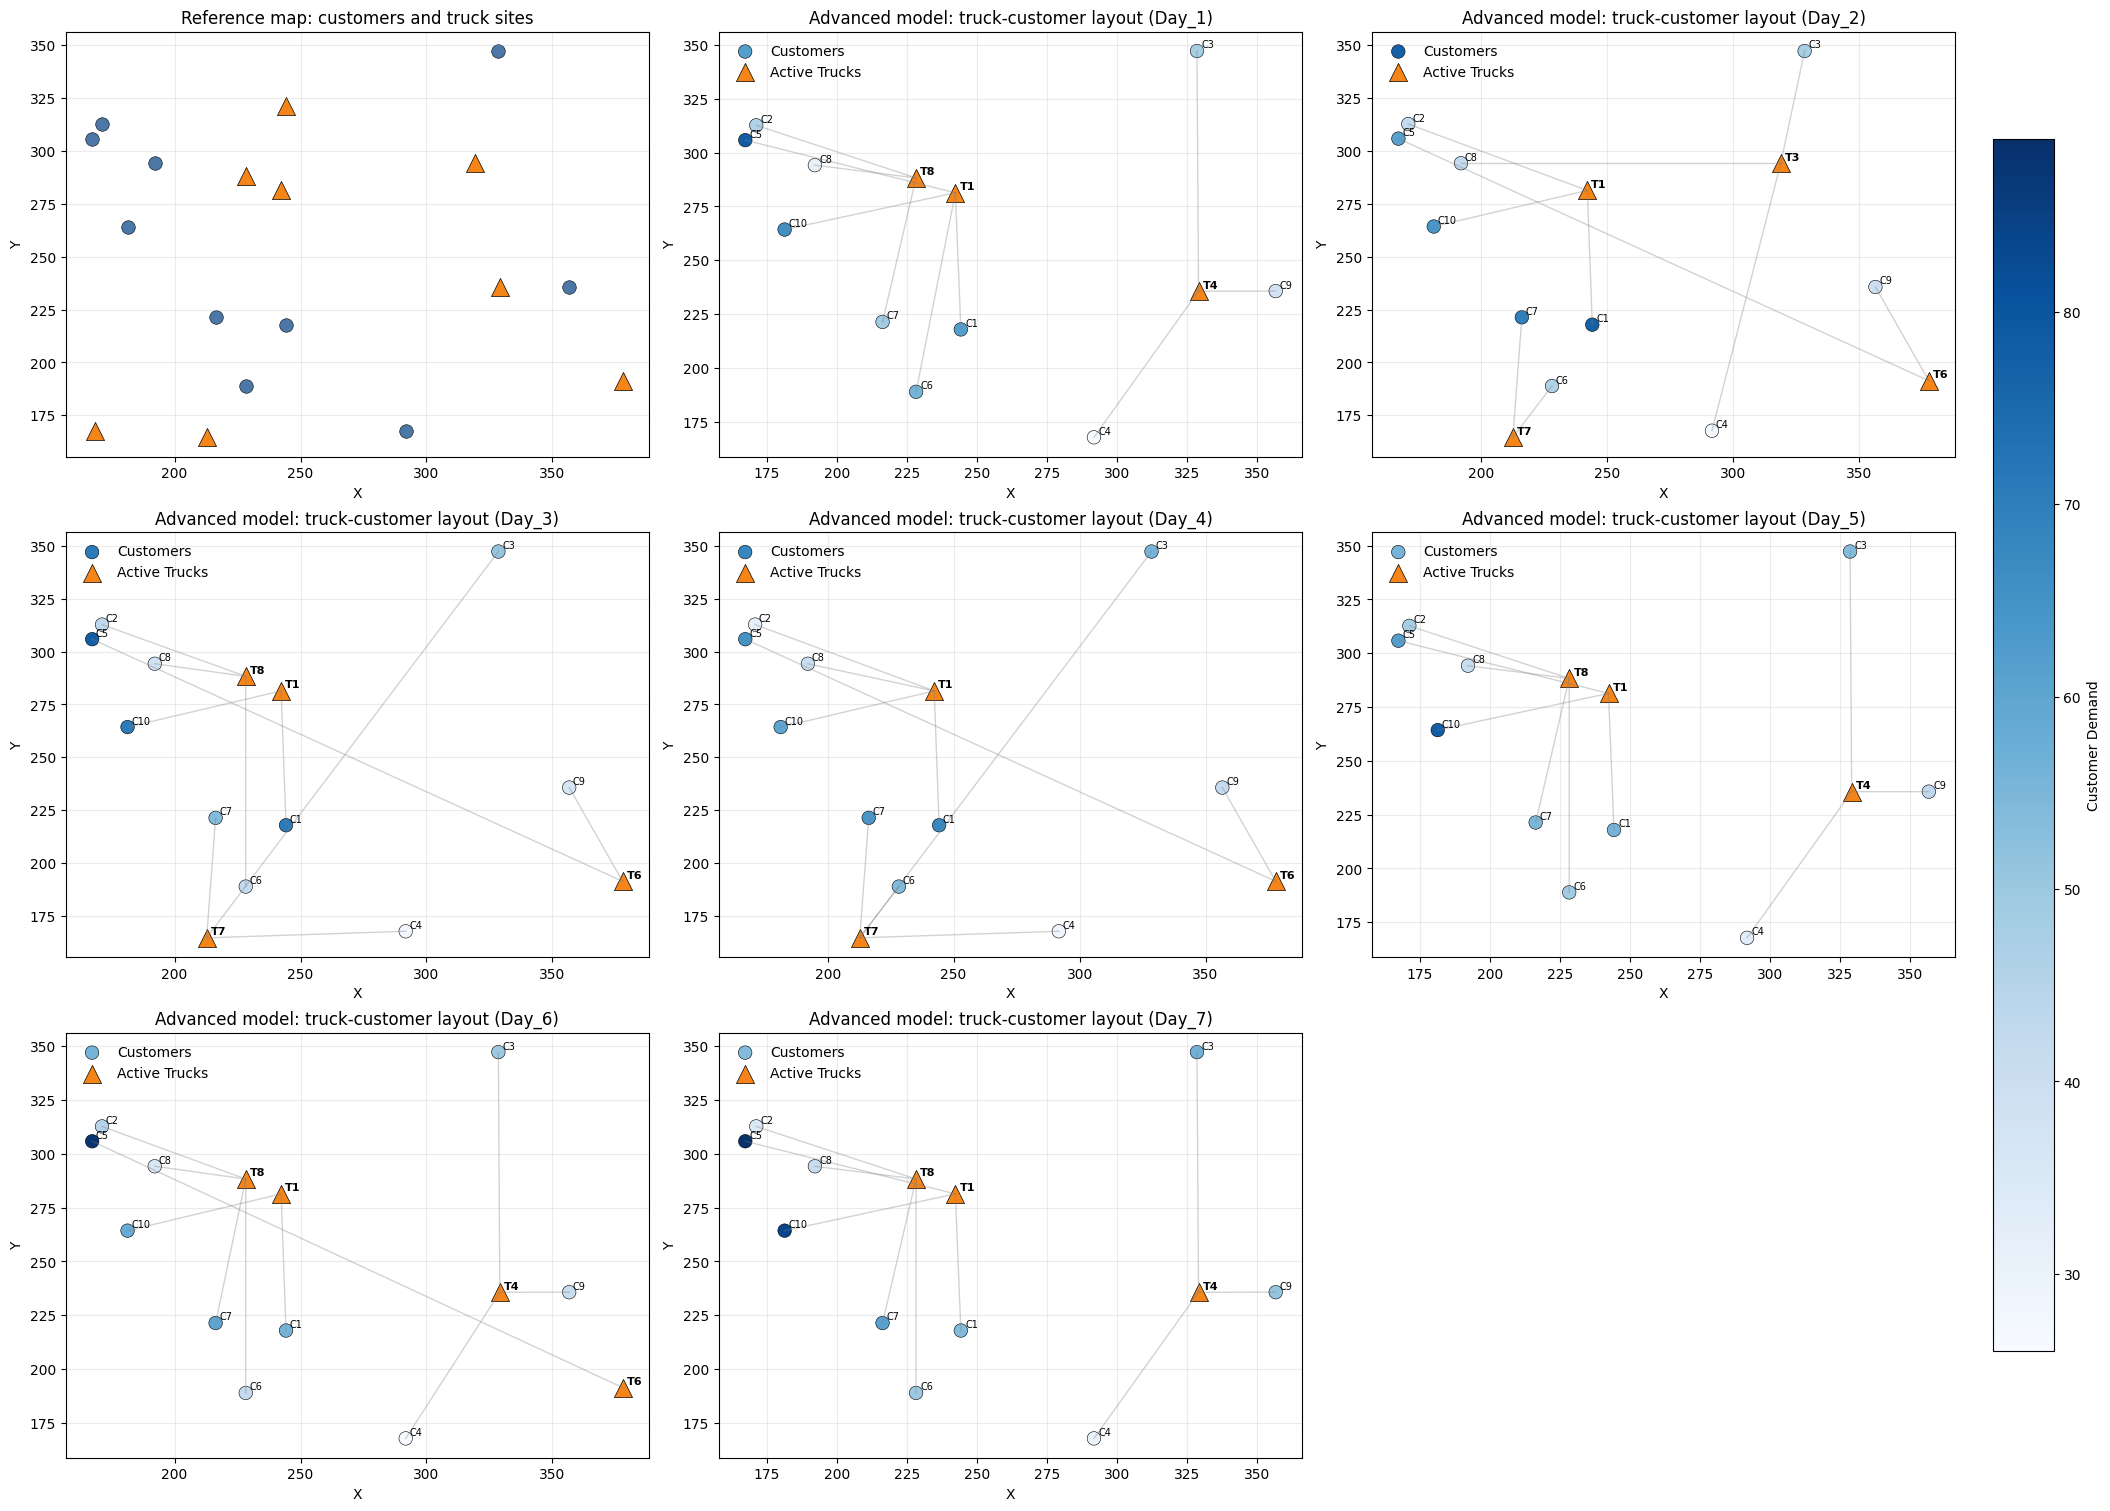

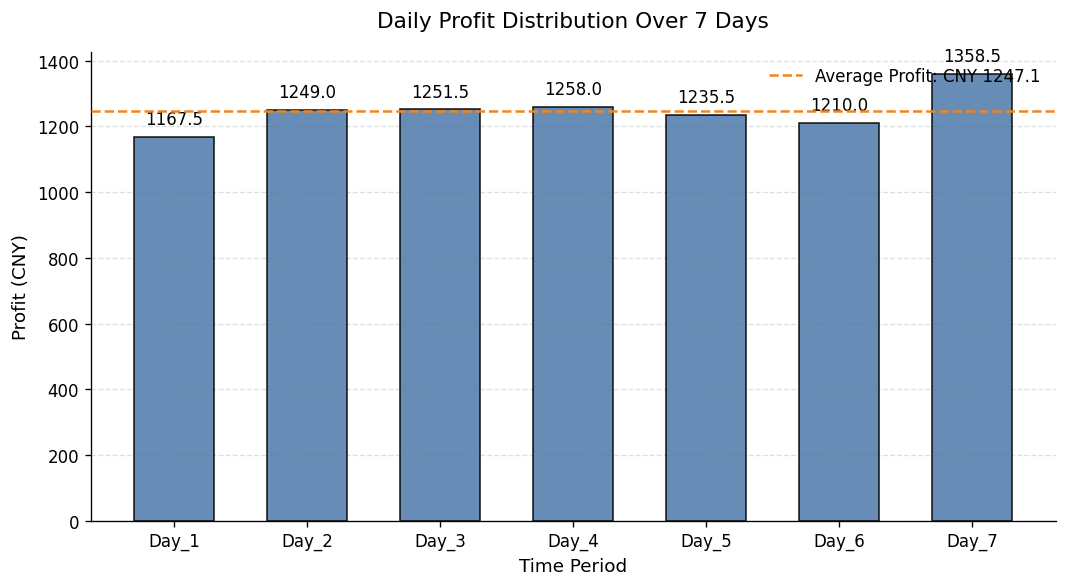

In [7]:
import os
import math
import pandas as pd
import numpy as np
import gurobipy as gp
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from gurobipy import GRB

# 1. 核心参数与原始数据
R, K = 10.0, 5.0
DAYS = 7

data_dir = "datas"

TRUCK_TYPES = ["Small", "Medium", "Large"]
TRUCK_CAPACITY = {"Small": 100, "Medium": 150, "Large": 200}
TRUCK_COST = {"Small": 180.0, "Medium": 250.0, "Large": 320.0}

customers = [f"C{i+1}" for i in range(10)]
locations = [f"T{j+1}" for j in range(8)]
time_periods = [f"Day_{t}" for t in range(1, DAYS + 1)]

alpha = {
    "C1":  {"T1": 0.9, "T2": 0.7, "T3": 0.2, "T4": 0.1, "T5": 0.0, "T6": 0.3, "T7": 0.6, "T8": 0.4},
    "C2":  {"T1": 0.4, "T2": 0.8, "T3": 0.1, "T4": 0.0, "T5": 0.6, "T6": 0.2, "T7": 0.3, "T8": 0.7},
    "C3":  {"T1": 0.2, "T2": 0.3, "T3": 0.9, "T4": 0.5, "T5": 0.1, "T6": 0.0, "T7": 0.6, "T8": 0.4},
    "C4":  {"T1": 0.1, "T2": 0.0, "T3": 0.4, "T4": 0.8, "T5": 0.9, "T6": 0.3, "T7": 0.5, "T8": 0.2},
    "C5":  {"T1": 0.7, "T2": 0.6, "T3": 0.3, "T4": 0.0, "T5": 0.4, "T6": 0.9, "T7": 0.1, "T8": 0.5},
    "C6":  {"T1": 0.5, "T2": 0.2, "T3": 0.1, "T4": 0.3, "T5": 0.6, "T6": 0.4, "T7": 0.8, "T8": 0.7},
    "C7":  {"T1": 0.3, "T2": 0.4, "T3": 0.0, "T4": 0.6, "T5": 0.2, "T6": 0.1, "T7": 0.9, "T8": 0.8},
    "C8":  {"T1": 0.6, "T2": 0.5, "T3": 0.7, "T4": 0.1, "T5": 0.3, "T6": 0.0, "T7": 0.2, "T8": 0.9},
    "C9":  {"T1": 0.2, "T2": 0.1, "T3": 0.6, "T4": 0.9, "T5": 0.4, "T6": 0.8, "T7": 0.0, "T8": 0.3},
    "C10": {"T1": 0.8, "T2": 0.3, "T3": 0.5, "T4": 0.2, "T5": 0.7, "T6": 0.1, "T7": 0.4, "T8": 0.6},
}

df_demand_10 = pd.read_csv(os.path.join(data_dir, "advanced_model_7day_demand.csv"), index_col=0)
d_it = df_demand_10.to_dict()

# 2. 模型构建
m = gp.Model("Advanced_Model_10_Customers_Comparison")

x = m.addVars(locations, time_periods, TRUCK_TYPES, vtype=GRB.BINARY, name="x")
y = m.addVars(customers, locations, time_periods, vtype=GRB.BINARY, name="y")

obj = gp.quicksum((R - K) * alpha[i][j] * d_it[t][i] * y[i, j, t] for i in customers for j in locations for t in time_periods) - \
      gp.quicksum(TRUCK_COST[m_type] * x[j, t, m_type] for j in locations for t in time_periods for m_type in TRUCK_TYPES)
m.setObjective(obj, GRB.MAXIMIZE)

# C1: 每天每位顾客最多被服务一次
m.addConstrs((y.sum(i, '*', t) <= 1 for i in customers for t in time_periods), "C1")

# C2: 每天每个位置最多部署一辆餐车
m.addConstrs((x.sum(j, t, '*') <= 1 for j in locations for t in time_periods), "C2")

# C3: 只有位置开启车型后才能分配顾客
m.addConstrs((y[i, j, t] <= x.sum(j, t, '*') for i in customers for j in locations for t in time_periods), "C3")

# C4: 每个位置每天的有效需求不超过车型容量
m.addConstrs((gp.quicksum(alpha[i][j] * d_it[t][i] * y[i, j, t] for i in customers) <=
              gp.quicksum(TRUCK_CAPACITY[mt] * x[j, t, mt] for mt in TRUCK_TYPES)
              for j in locations for t in time_periods), "C4")

m.Params.OutputFlag = 0
m.optimize()

# 3. 输出结果
if m.status == GRB.OPTIMAL:
    print(f"7天总利润 (含波动与容量限制): CNY {m.ObjVal:.2f}")
    print(f"平均单日利润: CNY {m.ObjVal / 7:.2f}")

    res_list = []
    for t in time_periods:
        for j in locations:
            for mt in TRUCK_TYPES:
                if x[j, t, mt].X > 0.5:
                    served = [i for i in customers if y[i, j, t].X > 0.5]
                    res_list.append(
                        {
                            "Day": t,
                            "Location": j,
                            "Truck_Type": mt,
                            "Customers_Served": len(served),
                            "Daily_Profit_Contribution": sum((R - K) * alpha[i][j] * d_it[t][i] for i in served) - TRUCK_COST[mt],
                        }
                    )

    df_res = pd.DataFrame(res_list)
    os.makedirs(data_dir, exist_ok=True)
    df_res.to_csv(os.path.join(data_dir, "advanced_10_cust_strict_comparison.csv"), index=False)
    print("结果已保存至 datas/advanced_10_cust_strict_comparison.csv")
    print("\n--- 每日车型部署摘要 ---")
    print(df_res.groupby("Day")["Truck_Type"].value_counts().unstack().fillna(0))

    # 4. 可视化：使用反解坐标
    if "cust_xy" not in globals() or "loc_xy" not in globals():
        raise ValueError("请先运行第3部分（alpha 反解坐标）再运行本单元可视化。")

    cust_xy_map = {customers[i]: cust_xy[i] for i in range(len(customers))}
    loc_xy_map = {locations[j]: loc_xy[j] for j in range(len(locations))}

    day_labels = sorted(time_periods, key=lambda x: int(x.split("_")[1]))
    n_days = len(day_labels)
    all_day_demands = [d_it[day][c] for day in day_labels for c in customers]
    demand_norm = Normalize(vmin=min(all_day_demands), vmax=max(all_day_demands))

    def plot_reference_map(ax):
        ax.scatter(
            [cust_xy_map[c][0] for c in customers],
            [cust_xy_map[c][1] for c in customers],
            s=95,
            c="#4C78A8",
            edgecolors="black",
            linewidths=0.4,
            label="Customers",
        )
        ax.scatter(
            [loc_xy_map[j][0] for j in locations],
            [loc_xy_map[j][1] for j in locations],
            marker="^",
            s=170,
            c="#F58518",
            edgecolors="black",
            linewidths=0.5,
            label="Truck Sites",
        )
        ax.set_title("Reference map: customers and truck sites")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.grid(alpha=0.25)

    def plot_one_day(ax, day_label):
        demand_values = [d_it[day_label][c] for c in customers]
        sc = ax.scatter(
            [cust_xy_map[c][0] for c in customers],
            [cust_xy_map[c][1] for c in customers],
            c=demand_values,
            cmap="Blues",
            norm=demand_norm,
            s=95,
            edgecolors="black",
            linewidths=0.4,
            label="Customers",
        )

        active_locations = []
        active_types = {}
        for j in locations:
            for mt in TRUCK_TYPES:
                if x[j, day_label, mt].X > 0.5:
                    active_locations.append(j)
                    active_types[j] = mt

        if active_locations:
            lx = [loc_xy_map[j][0] for j in active_locations]
            ly = [loc_xy_map[j][1] for j in active_locations]
            ax.scatter(lx, ly, marker="^", s=170, c="#F58518", edgecolors="black", linewidths=0.5, label="Active Trucks")

        for c in customers:
            assigned_loc = None
            for j in locations:
                if y[c, j, day_label].X > 0.5:
                    assigned_loc = j
                    break
            if assigned_loc is not None:
                x1, y1 = cust_xy_map[c]
                x2, y2 = loc_xy_map[assigned_loc]
                ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.35, linewidth=1.0)

        for c in customers:
            x_c, y_c = cust_xy_map[c]
            ax.text(x_c + 1.5, y_c + 1.5, c, fontsize=7)
        for j in active_locations:
            x_j, y_j = loc_xy_map[j]
            ax.text(x_j + 1.5, y_j + 1.5, j, fontsize=8, fontweight="bold")

        ax.set_title(f"Advanced model: truck-customer layout ({day_label})")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.grid(alpha=0.25)
        return sc

    if n_days == 1:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
        plot_reference_map(ax)
        plt.show()
    else:
        ncols = min(3, n_days + 1)
        nrows = math.ceil((n_days + 1) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False, constrained_layout=True)
        axes_flat = axes.flatten()

        plot_reference_map(axes_flat[0])
        last_sc = None
        for idx, day_label in enumerate(day_labels, start=1):
            last_sc = plot_one_day(axes_flat[idx], day_label)
            handles, labels = axes_flat[idx].get_legend_handles_labels()
            if labels:
                axes_flat[idx].legend(frameon=False, loc="best")

        for idx in range(n_days + 1, len(axes_flat)):
            axes_flat[idx].axis("off")

        if last_sc is not None:
            fig.colorbar(last_sc, ax=axes_flat[1:n_days + 1].tolist(), shrink=0.85, pad=0.02, label="Customer Demand")

        plt.show()
else:
    print("模型未找到最优解")

# 5. 可视化：七天各自总收益柱状图
if 'df_res' in locals() and not df_res.empty:
    # 按照 Day 分组并对利润求和
    daily_profit = df_res.groupby("Day")["Daily_Profit_Contribution"].sum()
    
    # 确保横坐标按照 Day_1 到 Day_7 的绝对时间顺序排列，缺失填0
    daily_profit = daily_profit.reindex(time_periods).fillna(0)
    
    # 设置高分辨率画布
    fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
    
    # 绘制柱状图，设置 zorder 置于网格线之上
    bars = ax.bar(daily_profit.index, daily_profit.values, 
                  color="#4C78A8", edgecolor="black", width=0.6, alpha=0.85, zorder=3)
    
    # 自动在柱体上方标注具体收益数值
    for bar in bars:
        yval = bar.get_height()
        # 根据 y 轴比例微调文字高度，避免与坐标系重叠
        offset = max(daily_profit.values) * 0.02 
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + offset, f'{yval:.1f}', 
                ha='center', va='bottom', fontsize=10, fontweight='medium')
    
    # 添加七天平均收益的基准线，便于直观评估波动情况
    avg_profit = daily_profit.mean()
    ax.axhline(avg_profit, color="#F58518", linestyle="--", linewidth=1.5, zorder=4, 
               label=f"Average Profit: CNY {avg_profit:.1f}")
    
    # 学术图表美化：去除顶部和右侧冗余边框，简化视觉
    ax.set_title("Daily Profit Distribution Over 7 Days", fontsize=13, pad=15)
    ax.set_xlabel("Time Period", fontsize=11)
    ax.set_ylabel("Profit (CNY)", fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.legend(frameon=False, loc="upper right")
    
    plt.tight_layout()
    plt.show()
else:
    print("未能读取到 df_res，无法绘制每日利润柱状图。")

## 6. Advanced Model 的 LP 松弛分析

In [8]:
# Advanced 模型 LP 松弛
lp_m = m.relax()
lp_m.optimize()

lp_obj_adv = lp_m.ObjVal
ip_obj_adv = m.ObjVal
gap_adv = (lp_obj_adv - ip_obj_adv) / ip_obj_adv * 100

print("--- 进阶模型对照 ---")
print(f"IP 最优利润: {ip_obj_adv:.2f}")
print(f"LP 松弛利润: {lp_obj_adv:.2f}")
print(f"Integrality Gap (整数间隙): {gap_adv:.2f}%")

print("\n【结构性洞察：未使用产能与紧约束】")
for t in time_periods[:1]:
    for j in locations:
        x_val = sum(lp_m.getVarByName(f"x[{j},{t},{m_type}]").X for m_type in TRUCK_TYPES)
        if x_val > 1e-5:
            con = lp_m.getConstrByName(f"C4[{j},{t}]")
            unused = con.Slack
            print(f"{t} 位置 {j}: 开启度 {x_val:.2f} | 约束松弛(未使用产能): {unused:.2f}")
            if abs(unused) < 1e-5:
                print("  此位置产能已达 Binding Constraint")

--- 进阶模型对照 ---
IP 最优利润: 8730.00
LP 松弛利润: 9191.38
Integrality Gap (整数间隙): 5.28%

【结构性洞察：未使用产能与紧约束】
Day_1 位置 T1: 开启度 0.98 | 约束松弛(未使用产能): 0.00
  此位置产能已达 Binding Constraint
Day_1 位置 T2: 开启度 0.02 | 约束松弛(未使用产能): 0.00
  此位置产能已达 Binding Constraint
Day_1 位置 T3: 开启度 0.20 | 约束松弛(未使用产能): 4.21
Day_1 位置 T5: 开启度 0.18 | 约束松弛(未使用产能): 0.00
  此位置产能已达 Binding Constraint
Day_1 位置 T6: 开启度 0.99 | 约束松弛(未使用产能): 0.00
  此位置产能已达 Binding Constraint
Day_1 位置 T7: 开启度 0.63 | 约束松弛(未使用产能): 0.00
  此位置产能已达 Binding Constraint
Day_1 位置 T8: 开启度 0.80 | 约束松弛(未使用产能): 0.00
  此位置产能已达 Binding Constraint


## 7. 自生成实例（Scalability）求解与可视化

求解成功！
7天总利润: CNY 3806.65
  Day  Active_Trucks
Day_1              2
Day_2              2
Day_3              2
Day_4              2
Day_5              2
Day_6              2
Day_7              2


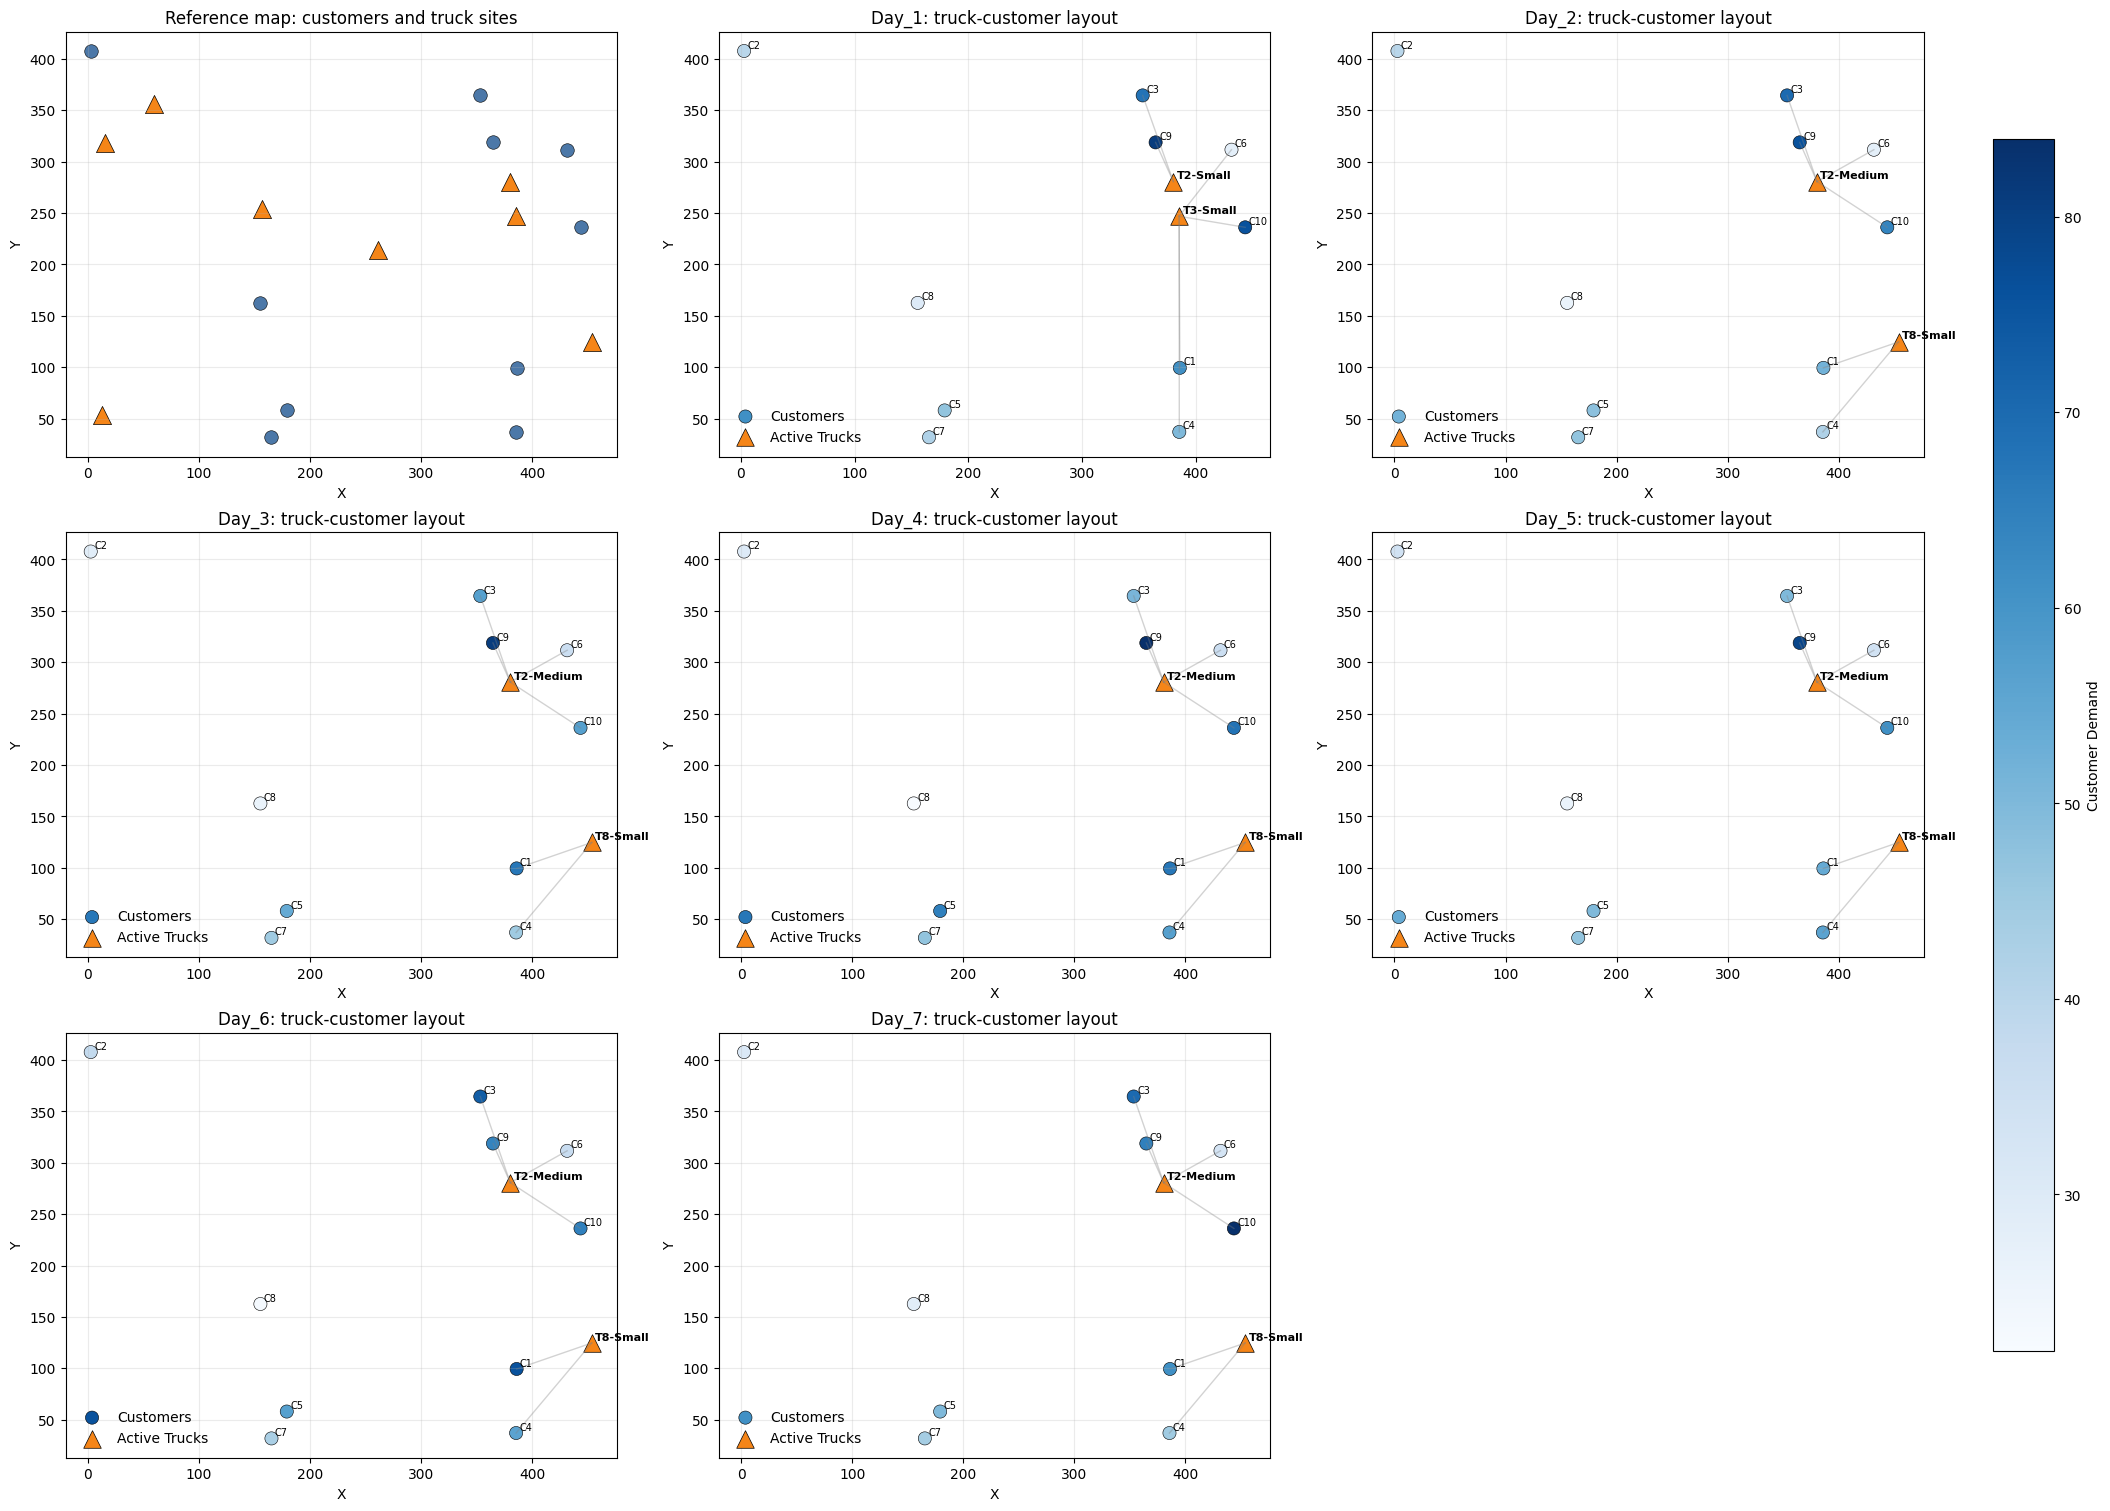

In [9]:
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import math
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# 1. 读取自生成数据
df_cust_gen = pd.read_csv("datas/scalability_customer_data.csv", index_col=0)
df_loc_gen = pd.read_csv("datas/scalability_location_coords.csv", index_col=0)
df_alpha_gen = pd.read_csv("datas/scalability_alpha_matrix.csv", index_col=0)

gen_customers = df_cust_gen.index.tolist()
gen_locations = df_loc_gen.index.tolist()
gen_demands = df_cust_gen["Base_Demand"].to_dict()
gen_alpha = df_alpha_gen.to_dict()

# 2. 模拟 7 天需求
np.random.seed(42)
gen_d_it = {}
for t in range(1, 8):
    day = f"Day_{t}"
    gen_d_it[day] = {i: max(0, int(np.round(gen_demands[i] * (1 + np.random.uniform(-0.2, 0.2))))) for i in gen_customers}

# 3. 构建模型
m_gen = gp.Model("Advanced_Model_Self_Generated")

x_gen = m_gen.addVars(gen_locations, [f"Day_{t}" for t in range(1, 8)], TRUCK_TYPES, vtype=GRB.BINARY, name="x_gen")
y_gen = m_gen.addVars(gen_customers, gen_locations, [f"Day_{t}" for t in range(1, 8)], vtype=GRB.BINARY, name="y_gen")

obj_gen = gp.quicksum((R - K) * gen_alpha[j][i] * gen_d_it[t][i] * y_gen[i, j, t]
                      for i in gen_customers for j in gen_locations for t in [f"Day_{t}" for t in range(1, 8)]) - \
          gp.quicksum(TRUCK_COST[m_type] * x_gen[j, t, m_type]
                      for j in gen_locations for t in [f"Day_{t}" for t in range(1, 8)] for m_type in TRUCK_TYPES)
m_gen.setObjective(obj_gen, GRB.MAXIMIZE)

m_gen.addConstrs((y_gen.sum(i, '*', t) <= 1 for i in gen_customers for t in [f"Day_{t}" for t in range(1, 8)]), "C1")
m_gen.addConstrs((x_gen.sum(j, t, '*') <= 1 for j in gen_locations for t in [f"Day_{t}" for t in range(1, 8)]), "C2")
m_gen.addConstrs((y_gen[i, j, t] <= x_gen.sum(j, t, '*') for i in gen_customers for j in gen_locations for t in [f"Day_{t}" for t in range(1, 8)]), "C3")
m_gen.addConstrs((gp.quicksum(gen_alpha[j][i] * gen_d_it[t][i] * y_gen[i, j, t] for i in gen_customers) <=
                  gp.quicksum(TRUCK_CAPACITY[mt] * x_gen[j, t, mt] for mt in TRUCK_TYPES)
                  for j in gen_locations for t in [f"Day_{t}" for t in range(1, 8)]), "C4")

m_gen.Params.OutputFlag = 0
m_gen.optimize()

if m_gen.status == GRB.OPTIMAL:
    print("求解成功！")
    print(f"7天总利润: CNY {m_gen.ObjVal:.2f}")

    summary = []
    for t in [f"Day_{t}" for t in range(1, 8)]:
        active_trucks = sum(1 for j in gen_locations for mt in TRUCK_TYPES if x_gen[j, t, mt].X > 0.5)
        summary.append({"Day": t, "Active_Trucks": active_trucks})
    print(pd.DataFrame(summary).to_string(index=False))

    # 4. 可视化
    day_labels = sorted(gen_d_it.keys(), key=lambda x: int(x.split("_")[1]))
    n_days = len(day_labels)
    all_day_demands = [gen_d_it[day][c] for day in day_labels for c in gen_customers]
    demand_norm = Normalize(vmin=min(all_day_demands), vmax=max(all_day_demands))

    def plot_reference_map(ax):
        ax.scatter(
            df_cust_gen["X_Coord"],
            df_cust_gen["Y_Coord"],
            s=95,
            c="#4C78A8",
            edgecolors="black",
            linewidths=0.4,
            label="Customers",
        )
        ax.scatter(
            df_loc_gen["X_Coord"],
            df_loc_gen["Y_Coord"],
            marker="^",
            s=170,
            c="#F58518",
            edgecolors="black",
            linewidths=0.5,
            label="Truck Sites",
        )
        ax.set_title("Reference map: customers and truck sites")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.grid(alpha=0.25)

    def plot_one_day(ax, day_label):
        demand_values = [gen_d_it[day_label][c] for c in gen_customers]
        sc = ax.scatter(
            df_cust_gen["X_Coord"],
            df_cust_gen["Y_Coord"],
            c=demand_values,
            cmap="Blues",
            norm=demand_norm,
            s=90,
            edgecolors="black",
            linewidths=0.4,
            label="Customers",
        )

        active_locations = []
        active_types = {}
        for j in gen_locations:
            for mt in TRUCK_TYPES:
                if x_gen[j, day_label, mt].X > 0.5:
                    active_locations.append(j)
                    active_types[j] = mt

        if active_locations:
            loc_xy = df_loc_gen.loc[active_locations, ["X_Coord", "Y_Coord"]]
            ax.scatter(
                loc_xy["X_Coord"],
                loc_xy["Y_Coord"],
                marker="^",
                s=160,
                c="#F58518",
                edgecolors="black",
                linewidths=0.5,
                label="Active Trucks",
            )

        for c in gen_customers:
            assigned_loc = None
            for j in gen_locations:
                if y_gen[c, j, day_label].X > 0.5:
                    assigned_loc = j
                    break
            if assigned_loc is not None:
                x1, y1 = df_cust_gen.loc[c, ["X_Coord", "Y_Coord"]]
                x2, y2 = df_loc_gen.loc[assigned_loc, ["X_Coord", "Y_Coord"]]
                ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.35, linewidth=1.0)

        for c in gen_customers:
            x_c, y_c = df_cust_gen.loc[c, ["X_Coord", "Y_Coord"]]
            ax.text(x_c + 3, y_c + 3, c, fontsize=7)
        for j in active_locations:
            x_j, y_j = df_loc_gen.loc[j, ["X_Coord", "Y_Coord"]]
            ax.text(x_j + 3, y_j + 3, f"{j}-{active_types[j]}", fontsize=8, fontweight="bold")

        ax.set_title(f"{day_label}: truck-customer layout")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.grid(alpha=0.25)
        return sc

    if n_days == 1:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
        plot_reference_map(ax)
        plt.show()
    else:
        ncols = min(3, n_days + 1)
        nrows = math.ceil((n_days + 1) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False, constrained_layout=True)
        axes_flat = axes.flatten()

        plot_reference_map(axes_flat[0])
        last_sc = None
        for idx, day_label in enumerate(day_labels, start=1):
            last_sc = plot_one_day(axes_flat[idx], day_label)
            handles, labels = axes_flat[idx].get_legend_handles_labels()
            if labels:
                axes_flat[idx].legend(frameon=False, loc="best")

        for idx in range(n_days + 1, len(axes_flat)):
            axes_flat[idx].axis("off")

        if last_sc is not None:
            fig.colorbar(last_sc, ax=axes_flat[1:n_days + 1].tolist(), shrink=0.85, pad=0.02, label="Customer Demand")

        plt.show()
else:
    print("模型未找到最优解")

数据清洗与编码完成！当前有效数据维度为: (284, 66)



规模: 10 客户, 6 位置
  贪心启发式: profit=1882.65, time=0.00s
  PuLP-CBC: status=Optimal, profit=2108.1499999999996, gap=0.0, time=0.09s
  Gurobi: status=OPTIMAL, profit=2108.15, gap=0.0, time=0.01s

规模: 20 客户, 8 位置
  贪心启发式: profit=4556.15, time=0.01s
  PuLP-CBC: status=Optimal, profit=4470.000000000001, gap=0.0, time=0.35s
  Gurobi: status=OPTIMAL, profit=4470.0, gap=0.0, time=0.02s

规模: 50 客户, 10 位置
  贪心启发式: profit=25360.45, time=0.02s
